# 02 — Health Data Preprocessing

Builds two analysis-ready CSVs from BF-Open-Data:

| Output | Contents |
|---|---|
| `data/processed/daily_city_health.csv` | Daily city-wide counts per climate-relevant dispatch code + aggregate EMS metrics + confounders |
| `data/processed/daily_district_health.csv` | Daily × district × dispatch code counts + confounders |

**Dispatch code classification**:
- `INCLUDE_CODES` — clear climate pathway (respiratory, cardiac, stroke, falls, fainting, heat/cold)
- `NEGATIVE_CONTROL_CODES` — violence/trauma; kept as separate columns to validate model specification
- Everything else excluded from primary analysis

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import holidays
import warnings
warnings.filterwarnings('ignore')

BF_ROOT  = Path('../BF-Open-Data/Datasets')
PROC_DIR = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded')

Libraries loaded


## 1. Dispatch Code Filter Lists

In [2]:
# Climate-sensitive outcomes — primary analysis targets
INCLUDE_CODES = [
    2,   # Allergy / venomous insect (pollen, summer insects)
    6,   # Breathing difficulties (O3, PM2.5, cold air, pollen)
    9,   # Cardiac / respiratory arrest (direct thermal cardiac effect)
    10,  # Chest pain non-traumatic (temperature extremes)
    12,  # Seizure (heat-triggered, febrile)
    13,  # Blood sugar dysregulation (heat impairs insulin)
    17,  # Falls (ice/wet conditions in winter — largest single EMS category)
    18,  # Headache (heat, dehydration, barometric pressure)
    19,  # Heart problems / ICD (temperature extremes)
    20,  # Heat / cold exposure (directly climate-caused)
    28,  # Stroke / TIA (temperature + pollution)
    31,  # Loss of consciousness / fainting (heat, dehydration)
]

# Kept as negative control columns — should NOT correlate with climate
NEGATIVE_CONTROL_CODES = {
    4:  'assault',
    27: 'stabbing_gunshot',
    29: 'traffic_accident',
    30: 'injuries_trauma',
}

CODE_NAMES = {
    2:  'allergy_insect',
    6:  'breathing',
    9:  'cardiac_arrest',
    10: 'chest_pain',
    12: 'seizure',
    13: 'blood_sugar',
    17: 'falls',
    18: 'headache',
    19: 'heart_problems',
    20: 'heat_cold_exposure',
    28: 'stroke_tia',
    31: 'loss_of_consciousness',
}

ALL_CODES_TO_LOAD = INCLUDE_CODES + list(NEGATIVE_CONTROL_CODES.keys())
print(f'Loading {len(INCLUDE_CODES)} climate-sensitive codes + {len(NEGATIVE_CONTROL_CODES)} negative controls')

Loading 12 climate-sensitive codes + 4 negative controls


## 2. Load Mission Data (2018–2026)

In [3]:
MISSION_DIR = BF_ROOT / 'Mission_Data'
YEARS = range(2018, 2027)

dfs = []
for year in YEARS:
    fpath = MISSION_DIR / f'mission_data_set_open_data_{year}.csv'
    if not fpath.exists():
        print(f'{year}: file not found, skipping')
        continue
    df = pd.read_csv(
        fpath,
        usecols=['mission_date', 'mission_type', 'dispatchcode_category',
                 'dispatchcode_category_name', 'mission_location_district'],
        low_memory=False
    )
    df['year_source'] = year
    dfs.append(df)
    print(f'{year}: {len(df):,} rows')

raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows loaded: {len(raw):,}')

2018: 463,684 rows


2019: 472,638 rows


2020: 466,774 rows


2021: 489,860 rows


2022: 526,743 rows


2023: 512,885 rows


2024: 532,575 rows


2025: 556,862 rows
2026: 198,261 rows



Total rows loaded: 4,220,282


In [4]:
# Parse date and apply filters
raw['date'] = pd.to_datetime(raw['mission_date'], errors='coerce')
raw['dispatchcode_category'] = pd.to_numeric(raw['dispatchcode_category'], errors='coerce')

# Keep EMS only
ems = raw[raw['mission_type'] == 'Rettungsdienst'].copy()
print(f'EMS missions: {len(ems):,} ({len(ems)/len(raw)*100:.1f}% of total)')

# Keep only coded rows
ems = ems.dropna(subset=['date', 'dispatchcode_category'])
ems['dispatchcode_category'] = ems['dispatchcode_category'].astype(int)
print(f'After dropping uncoded / unparseable rows: {len(ems):,}')
print(f'Date range: {ems.date.min().date()} → {ems.date.max().date()}')

EMS missions: 3,615,650 (85.7% of total)
After dropping uncoded / unparseable rows: 3,367,274
Date range: 2018-01-01 → 2026-05-08


## 3. City-Wide Daily Aggregation

In [5]:
# Subset to codes we want
ems_subset = ems[ems['dispatchcode_category'].isin(ALL_CODES_TO_LOAD)].copy()

# City-wide: count missions per (date, code)
city_long = (
    ems_subset
    .groupby(['date', 'dispatchcode_category'])
    .size()
    .reset_index(name='count')
)

# Pivot to wide: one row per date, one column per code
city_wide = city_long.pivot_table(
    index='date', columns='dispatchcode_category', values='count', fill_value=0
).reset_index()

# Rename columns
rename_map = {}
for code, name in CODE_NAMES.items():
    if code in city_wide.columns:
        rename_map[code] = f'code_{code:02d}_{name}'
for code, name in NEGATIVE_CONTROL_CODES.items():
    if code in city_wide.columns:
        rename_map[code] = f'ctrl_{code:02d}_{name}'

city_wide.columns = [
    rename_map.get(c, c) if c != 'date' else 'date'
    for c in city_wide.columns
]

print(f'City-wide table: {city_wide.shape[0]} days × {city_wide.shape[1]} columns')
city_wide.head(3)

City-wide table: 3050 days × 17 columns


,date,code_02_allergy_insect,ctrl_04_assault,code_06_breathing,code_09_cardiac_arrest,code_10_chest_pain,code_12_seizure,code_13_blood_sugar,code_17_falls,code_18_headache,code_19_heart_problems,code_20_heat_cold_exposure,ctrl_27_stabbing_gunshot,code_28_stroke_tia,ctrl_29_traffic_accident,ctrl_30_injuries_trauma,code_31_loss_of_consciousness
0,2018-01-01,8.0,25.0,110.0,14.0,54.0,30.0,17.0,156.0,4.0,51.0,0.0,0.0,30.0,0.0,153.0,110.0
1,2018-01-02,5.0,3.0,104.0,14.0,68.0,21.0,8.0,112.0,7.0,30.0,0.0,0.0,20.0,0.0,50.0,65.0
2,2018-01-03,3.0,3.0,101.0,10.0,55.0,26.0,13.0,98.0,6.0,47.0,0.0,0.0,21.0,1.0,48.0,83.0


## 4. Merge Aggregate EMS Metrics from BFw_mission_data_daily

In [6]:
daily_path = BF_ROOT / 'Daily_Data' / 'BFw_mission_data_daily.csv'
daily_agg = pd.read_csv(daily_path, parse_dates=['mission_created_date'], low_memory=False)

# Keep the aggregate EMS columns and response time columns
agg_cols = ['mission_created_date'] + [
    c for c in daily_agg.columns
    if any(k in c for k in ['mission_count_ems', 'mission_count_rd',
                             'response_time_ems', 'response_time_fire',
                             'time_goal'])
]
daily_agg = daily_agg[agg_cols].rename(columns={'mission_created_date': 'date'})

city_wide = city_wide.merge(daily_agg, on='date', how='left')
print(f'After merging aggregate metrics: {city_wide.shape}')

After merging aggregate metrics: (3050, 40)


## 5. Add Confounder Columns

In [7]:
def add_confounders(df, date_col='date'):
    df = df.copy()
    d = df[date_col]

    df['day_of_week']  = d.dt.dayofweek          # 0=Monday, 6=Sunday
    df['is_weekend']   = d.dt.dayofweek >= 5
    df['month']        = d.dt.month
    df['day_of_year']  = d.dt.dayofyear
    df['year']         = d.dt.year
    df['week_of_year'] = d.dt.isocalendar().week.astype(int)

    # German federal + Berlin state public holidays
    be_holidays = holidays.Germany(state='BE', years=range(2017, 2027))
    df['is_public_holiday'] = d.dt.date.map(lambda x: x in be_holidays).astype(int)

    # COVID indicator: first lockdown announcement to end of major restrictions
    covid_start = pd.Timestamp('2020-03-15')
    covid_end   = pd.Timestamp('2021-06-30')
    df['covid_flag'] = ((d >= covid_start) & (d <= covid_end)).astype(int)

    # Cyclical encoding for day_of_year (preserves circular continuity for models)
    df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

    return df

city_wide = add_confounders(city_wide)
print('Confounders added:', ['day_of_week','is_weekend','month','day_of_year',
                              'year','is_public_holiday','covid_flag','doy_sin','doy_cos'])

Confounders added: ['day_of_week', 'is_weekend', 'month', 'day_of_year', 'year', 'is_public_holiday', 'covid_flag', 'doy_sin', 'doy_cos']


## 6. District-Level Daily Aggregation

In [8]:
# District panel: only climate-sensitive codes (no negative controls needed per-district)
dist_ems = ems[ems['dispatchcode_category'].isin(INCLUDE_CODES)].copy()
dist_ems = dist_ems.dropna(subset=['mission_location_district'])

dist_long = (
    dist_ems
    .groupby(['date', 'mission_location_district', 'dispatchcode_category'])
    .size()
    .reset_index(name='count')
)

dist_wide = dist_long.pivot_table(
    index=['date', 'mission_location_district'],
    columns='dispatchcode_category',
    values='count',
    fill_value=0
).reset_index()

# Rename code columns
dist_wide.columns = [
    (f'code_{int(c):02d}_{CODE_NAMES[int(c)]}' if c in CODE_NAMES else c)
    for c in dist_wide.columns
]

dist_wide = dist_wide.rename(columns={'mission_location_district': 'district'})
dist_wide = add_confounders(dist_wide)

print(f'District table: {dist_wide.shape[0]:,} rows × {dist_wide.shape[1]} columns')
print(f'Districts: {sorted(dist_wide["district"].unique())}')

District table: 36,600 rows × 24 columns
Districts: ['Charlottenburg-Wilmersdorf', 'Friedrichshain-Kreuzberg', 'Lichtenberg', 'Marzahn-Hellersdorf', 'Mitte', 'Neukölln', 'Pankow', 'Reinickendorf', 'Spandau', 'Steglitz-Zehlendorf', 'Tempelhof-Schöneberg', 'Treptow-Köpenick']


## 7. Save Outputs

In [9]:
city_out = PROC_DIR / 'daily_city_health.csv'
dist_out = PROC_DIR / 'daily_district_health.csv'

city_wide.sort_values('date').to_csv(city_out, index=False)
dist_wide.sort_values(['date', 'district']).to_csv(dist_out, index=False)

print(f'Saved: {city_out}  ({city_wide.shape[0]} rows, {city_wide.shape[1]} cols)')
print(f'Saved: {dist_out}  ({dist_wide.shape[0]} rows, {dist_wide.shape[1]} cols)')

Saved: ../data/processed/daily_city_health.csv  (3050 rows, 50 cols)
Saved: ../data/processed/daily_district_health.csv  (36600 rows, 24 cols)


## 8. Summary Statistics & Validation

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = city_wide.copy()
print('=== City-wide dataset ===')
print(f'Date range : {df.date.min().date()} → {df.date.max().date()}')
print(f'Total days : {len(df)}')
print(f'COVID days : {df.covid_flag.sum()}')
print(f'Holidays   : {df.is_public_holiday.sum()}')
print()

# Daily count stats per climate-sensitive code
code_cols = [c for c in df.columns if c.startswith('code_')]
print('Daily mission counts per dispatch category:')
print(df[code_cols].describe().round(1).T[['mean','std','min','50%','max']].to_string())

=== City-wide dataset ===
Date range : 2018-01-01 → 2026-05-08
Total days : 3050
COVID days : 473
Holidays   : 86

Daily mission counts per dispatch category:
                                mean   std   min    50%    max
code_02_allergy_insect           9.8   5.6   0.0    9.0   52.0
code_06_breathing              103.8  31.6  16.0  104.0  216.0
code_09_cardiac_arrest          12.4   4.0   1.0   12.0   30.0
code_10_chest_pain              64.4  17.8  22.0   62.0  136.0
code_12_seizure                 25.3   6.7   3.0   25.0   49.0
code_13_blood_sugar              9.5   3.3   1.0    9.0   22.0
code_17_falls                  155.7  38.8  41.0  153.0  873.0
code_18_headache                 8.9   3.8   0.0    9.0   25.0
code_19_heart_problems          57.0  17.9   9.0   60.0  108.0
code_20_heat_cold_exposure       1.3   2.1   0.0    1.0   20.0
code_28_stroke_tia              35.0   9.2  12.0   35.0   65.0
code_31_loss_of_consciousness  106.0  33.3   9.0  106.0  246.0


In [11]:
# Missing value report
missing = city_wide.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    print('Columns with missing values:')
    print(missing.to_string())
else:
    print('No missing values in code columns.')

# Negative control sanity: these should exist with small but non-zero counts
ctrl_cols = [c for c in city_wide.columns if c.startswith('ctrl_')]
print('\nNegative control columns (should be low, non-zero):')
print(city_wide[ctrl_cols].describe().round(1).T[['mean','std','min','max']].to_string())

Columns with missing values:
mission_count_ems                                 2
response_time_ems_critical_cpr_median             2
response_time_fire_time_to_full_crew_median       2
response_time_fire_time_to_full_crew_mean         2
response_time_fire_time_to_first_ladder_std       2
response_time_fire_time_to_first_ladder_median    2
response_time_fire_time_to_first_ladder_mean      2
response_time_fire_time_to_first_pump_std         2
response_time_fire_time_to_first_pump_median      2
response_time_fire_time_to_first_pump_mean        2
response_time_ems_critical_cpr_std                2
response_time_ems_critical_cpr_mean               2
mission_count_ems_critical                        2
response_time_ems_critical_std                    2
response_time_ems_critical_median                 2
response_time_ems_critical_mean                   2
mission_count_rd5                                 2
mission_count_rd4                                 2
mission_count_rd3                  

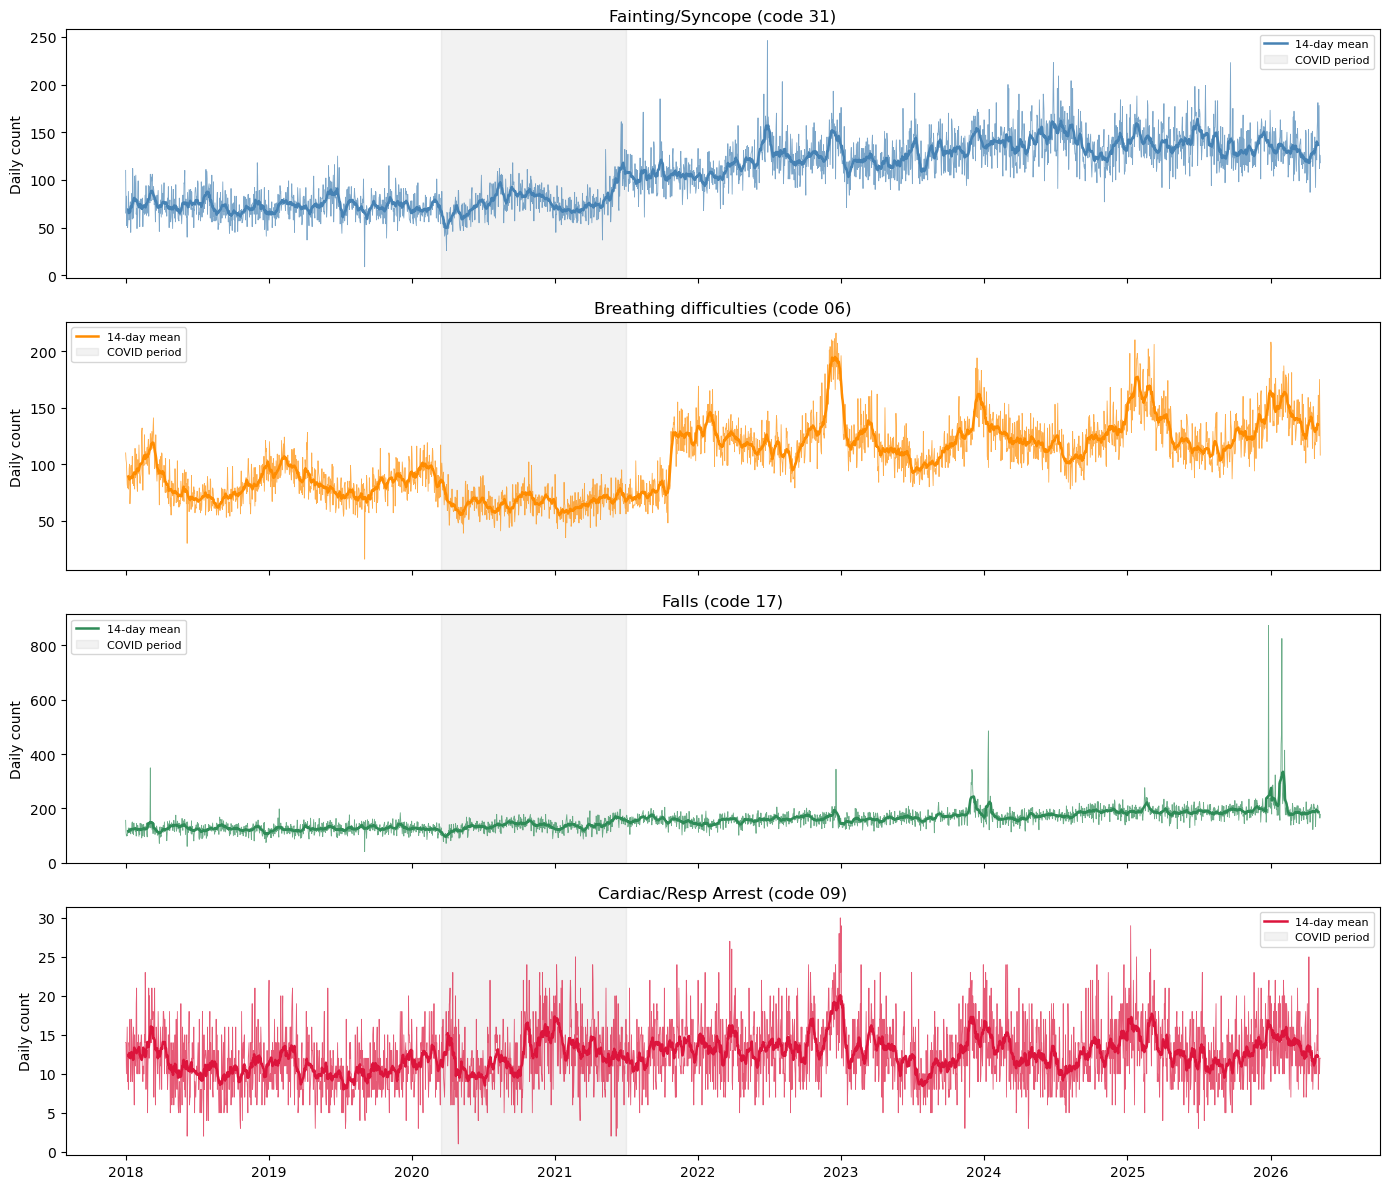

Plot saved to data/processed/health_time_series.png


In [12]:
# Time series plot of key outcomes
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

plot_pairs = [
    ('code_31_loss_of_consciousness', 'Fainting/Syncope (code 31)', 'steelblue'),
    ('code_06_breathing',             'Breathing difficulties (code 06)', 'darkorange'),
    ('code_17_falls',                  'Falls (code 17)', 'seagreen'),
    ('code_09_cardiac_arrest',         'Cardiac/Resp Arrest (code 09)', 'crimson'),
]

for ax, (col, title, color) in zip(axes, plot_pairs):
    if col not in city_wide.columns:
        ax.set_title(f'{title} — not found')
        continue
    ax.plot(city_wide['date'], city_wide[col], color=color, lw=0.6, alpha=0.7)
    # 14-day rolling mean
    ax.plot(city_wide['date'],
            city_wide[col].rolling(14, center=True).mean(),
            color=color, lw=1.8, label='14-day mean')
    ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2021-06-30'),
               alpha=0.1, color='gray', label='COVID period')
    ax.set_ylabel('Daily count')
    ax.set_title(title)
    ax.legend(fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.savefig(PROC_DIR / 'health_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to data/processed/health_time_series.png')